# Frog Call

#Dataset Description
This dataset was used in several classifications tasks related to the challenge of anuran species recognition through their calls. It is a multilabel dataset with three columns of labels. This dataset was created segmenting 60 audio records belonging to 4 different families, 8 genus, and 10 species. Each audio corresponds to one specimen (an individual frog), the record ID is also included as an extra column. We used the spectral entropy and a binary cluster method to detect audio frames belonging to each syllable. The segmentation and feature extraction were carried out in Matlab. After the segmentation we got 7195 syllables, which became instances for train and test the classifier. These records were collected in situ under real noise conditions (the background sound). Some species are from the campus of Federal University of Amazonas, Manaus, others from Mata Atlântica, Brazil, and one of them from Córdoba, Argentina. The recordings were stored in wav format with 44.1kHz of sampling frequency and 32bit of resolution, which allows us to analyze signals up to 22kHz. From every extracted syllable 22 MFCCs were calculated by using 44 triangular filters. These coefficients were normalized between -1 ≤ mfcc ≤ 1. The amount of instances per class are:

Families:
     Bufonidae              68 
     Dendrobatidae         542 
     Hylidae              2165 
     Leptodactylidae      4420 

Attribute =22

Label= 4 
Family labels are mapped into [0,1,2,3] 

Instance= 7195

### Method
Softmax Classification (regression) implementation for tensorflow.Train and Test accuracy compared. Unlike logistic regression softmax activation function used to predict labels at the end.In logistic regression sigmoid function predict the labels as binary [0,1] Here with softmax function we can make multiclass classification. 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
%matplotlib inline
from sklearn.cross_validation import train_test_split
tf.reset_default_graph()

frog = pd.read_csv("/Users/blue/Desktop/frog_data/Frogs_MFCCs.csv")

x= frog.iloc[:,:22].as_matrix() #features as matrix

y= frog['Family'].map({'Hylidae':0, 'Leptodactylidae':1, 'Bufonidae':2, 'Dendrobatidae':3}).as_matrix() #y labels also as_matrix()
print('Set_label', set(y))
y = pd.get_dummies(y) #one Hot encode the species column

print ("Dataset Shape:", frog.shape) #raw DATA shapes;
print ("x shape ", x.shape)
print ("y shape ", y.shape)



/Users/blue/anaconda/lib/python3.5/importlib/_bootstrap.py:222: RuntimeWarning: compiletime version 3.6 of module 'tensorflow.python.framework.fast_tensor_util' does not match runtime version 3.5
  return f(*args, **kwds)


Set_label {0, 1, 2, 3}
Dataset Shape: (7195, 26)
x shape  (7195, 22)
y shape  (7195, 4)


/Users/blue/anaconda/lib/python3.5/site-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


In [3]:
def create_placeholders(n):
    X = tf.placeholder(tf.float64, shape=(None, n))     # we use None for unspecified sample size m
    Y = tf.placeholder(tf.float64, shape=(None, 4))
    
    
    print('X',X.shape)
    print('Y',Y.shape)
    return X, Y

def init_params(n):
    W = tf.Variable(tf.truncated_normal(shape=(n, 4), dtype=tf.float64), trainable=True, name="weights")
    b = tf.Variable(tf.zeros(shape=(1, 4 ), dtype=tf.float64), trainable=True, name="bias")
    print('W=',W.shape)
    print('b',b.shape)
    return W, b
 
# model function not needed, as the call to tf.nn.sigmoid_cross_entropy_with_logits in compute_cost
# already computes the model prediction. see its help. 
def model(X, W, b):
    Z = tf.matmul(X,W) + b  # matrix multiplication not element-wise multiplication
    print('Z',Z.shape)
    print('Z type=',type(Z))
    return Z

def compute_cost(Y,Z):
    logits = Z 
    labels = Y  
    cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(logits=logits, labels=labels))
    return cost


def softmax(x, y, num_epochs, learning_rate, print_cost=True):
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 100)

    #normalization
    mean= np.mean(x, axis=1)
    mean= mean.reshape(mean.shape[0],1)
    print('mean_shape', mean.shape)

    var= np.var(x, axis=1)
    var= var.reshape(var.shape[0],1)
    print('var_shape', var.shape)

    x_norm= (x-mean)/var
    print('x_norm', x_norm.shape)
    
    print('X_train',X_train.shape)
    print('y_train',y_train.shape)
    print('y_train',type(y_train))
    print('X_test', X_test.shape)
    print('y_test',y_test.shape)
    
   
    
    graph = tf.Graph()
    with graph.as_default():
        m,n = X_train.shape
        costs = []
        X, Y = create_placeholders(n)
        W, b = init_params(n)
        Z = model(X, W, b)
        cost = compute_cost(Y,Z)
        optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate).minimize(cost) #training
        y_predict= tf.nn.softmax(Z)
        init = tf.global_variables_initializer()
        
    with tf.Session(graph=graph) as sess:
        sess.run(init)
        for epoch in range(num_epochs):
            _ , cost_ = sess.run([optimizer, cost], feed_dict={X:X_train, Y:y_train})
            costs.append(cost_)
            if print_cost == True and epoch % 1000 == 0:
                print ("Cost after epoch %i: %f" % (epoch, cost_))
        W_, b_ = sess.run([W, b])
        print('Z.shape=', Z.get_shape().as_list())
        print('Y.shape=', Y.get_shape().as_list())
        
        predictions = tf.equal(tf.argmax(y_predict,axis=1), tf.argmax(Y,axis=1))       
        accuracy = tf.reduce_mean(tf.cast(predictions, tf.float64))
        print('Train_Accuracy : ', sess.run(accuracy, feed_dict={X:X_train, Y:y_train}))
        print('Test_Accuracy : ', sess.run(accuracy, feed_dict={X:X_test, Y:y_test}))


    # plot the cost
    fig,ax = plt.subplots()
    ax.plot(np.squeeze(costs))
    ax.set_ylabel('cost')
    ax.set_xlabel('iterations')
    ax.set_title("Learning rate =" + str(learning_rate))
    #fig.show()
    return W_, b_  



mean_shape (7195, 1)
var_shape (7195, 1)
x_norm (7195, 22)
X_train (5036, 22)
y_train (5036, 4)
y_train <class 'pandas.core.frame.DataFrame'>
X_test (2159, 22)
y_test (2159, 4)
X (?, 22)
Y (?, 4)
W= (22, 4)
b (1, 4)
Z (?, 4)
Z type= <class 'tensorflow.python.framework.ops.Tensor'>
Cost after epoch 0: 2.171309
Cost after epoch 1000: 1.349479
Cost after epoch 2000: 1.099884
Cost after epoch 3000: 0.997270
Cost after epoch 4000: 0.937998
Cost after epoch 5000: 0.896991
Cost after epoch 6000: 0.865680
Cost after epoch 7000: 0.840263
Cost after epoch 8000: 0.818787
Cost after epoch 9000: 0.800147
Cost after epoch 10000: 0.783666
Cost after epoch 11000: 0.768900
Cost after epoch 12000: 0.755536
Cost after epoch 13000: 0.743350
Cost after epoch 14000: 0.732167
Cost after epoch 15000: 0.721851
Cost after epoch 16000: 0.712292
Cost after epoch 17000: 0.703398
Cost after epoch 18000: 0.695092
Cost after epoch 19000: 0.687312
Z.shape= [None, 4]
Y.shape= [None, 4]
Train_Accuracy :  0.631850675139


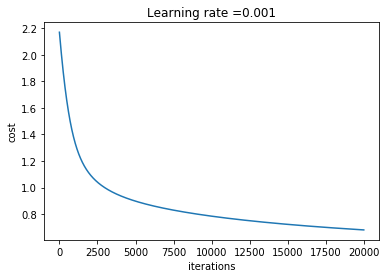

In [4]:
W, b = softmax(x, y, num_epochs=20000, learning_rate=1.e-3, print_cost=True, )

In [32]:
print(W, b)
print(-W[0,0]/W[0,1])


[[ 0.41959574  0.46738532 -0.16944654  0.88008746]
 [ 1.29429552  1.37575819 -1.52282742  0.49827256]
 [ 0.72788654 -0.19284781 -0.97965193 -2.59522762]
 [ 0.64466449  2.32390338 -0.78366917  0.5324093 ]
 [-0.87677678  0.22516548  0.55340887 -0.40534131]
 [ 1.10691827 -2.53913357 -1.15307456  0.03085038]
 [-2.05596603 -0.68630626 -1.14248484 -1.39096367]
 [-0.39394629 -1.43446568 -0.17010267 -0.17058303]
 [ 0.66418322  0.0634327   0.06940798 -1.52533716]
 [-1.03753917 -0.07205095 -0.74798947 -1.12325837]
 [ 1.67947011 -0.30556148 -0.79568476  0.31904675]
 [-0.2729875  -2.34935333 -0.31967156 -1.33023835]
 [-0.57248481  1.77401657 -1.08870492 -0.85567829]
 [ 0.120054   -0.39737809  0.36437825 -0.14692085]
 [-0.30606531 -0.59112834 -0.79559479  1.48447195]
 [-1.09998842 -1.17219382  0.18062464  0.26290861]
 [-0.195977    1.19997763 -0.87379782 -1.07208821]
 [ 0.33253688 -0.37628622  0.59116042  0.06901304]
 [ 1.73568237 -1.70976877  0.73026751  0.0793099 ]
 [ 0.90888967 -1.06584217  0.92

# Thyroid 
http://sci2s.ugr.es/keel/dataset.php?cod=67

This data set is one of the several databases about Thyroid available at the UCI repository. The task is to detect is a given patient is normal (1) 

suffers from hyperthyroidism (2) 

hypothyroidism (3) 

Data extensions and cross validations daatsets are given in the hyperlink

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
%matplotlib inline
from sklearn.cross_validation import train_test_split
tf.reset_default_graph()

thyroid = pd.read_csv('/Users/blue/Desktop/thyroid/thyroid 4.csv', header=None )


x= thyroid.iloc[:,:21].as_matrix()
y= thyroid.iloc[:, 21].as_matrix()
y = pd.get_dummies(y)

print ("Dataset Shape:", thyroid.shape)
print ("x shape ", x.shape)
print ("y shape ", y.shape)


Dataset Shape: (7200, 22)
x shape  (7200, 21)
y shape  (7200, 3)


In [76]:
def create_placeholders(n):
    X = tf.placeholder(tf.float64, shape=(None, n))     # we use None for unspecified sample size m
    Y = tf.placeholder(tf.float64, shape=(None, 3))
    print('X',X.shape)
    print('Y',Y.shape)
    return X, Y

def init_params(n):
    W = tf.Variable(tf.truncated_normal(shape=(n, 3), dtype=tf.float64), trainable=True, name="weights")
    b = tf.Variable(tf.zeros(shape=(1, 3 ), dtype=tf.float64), trainable=True, name="bias")
    print('W=',W.shape)
    print('b',b.shape)
    return W, b
 
# model function not needed, as the call to tf.nn.sigmoid_cross_entropy_with_logits in compute_cost
# already computes the model prediction. see its help. 
def model(X, W, b):
    Z = tf.matmul(X,W) + b  # matrix multiplication not element-wise multiplication
    print('Z',Z.shape)
    print('Z type=',type(Z))
    return Z

def compute_cost(Y,Z):
    logits = Z 
    labels = Y  
    cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(logits=logits, labels=labels))
    return cost


def softmax(x, y, num_epochs, learning_rate, print_cost=True):
    #normalization
    mean= np.mean(x, axis=1)
    mean= mean.reshape(mean.shape[0],1)
    print('mean_shape', mean.shape)

    var= np.var(x, axis=1)
    var= var.reshape(var.shape[0],1)
    print('var_shape', var.shape)

    x_norm= (x-mean)/var
    print('x_norm', x_norm.shape)
    
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.4, random_state = 100)

    print('X_train',X_train.shape)
    print('y_train',y_train.shape)
    print('y_train',type(y_train))
    print('X_test', X_test.shape)
    print('y_test',y_test.shape)
    
    graph = tf.Graph()
    with graph.as_default():
        m,n = X_train.shape
        costs = []
        X, Y = create_placeholders(n)
        W, b = init_params(n)
        Z = model(X, W, b)
        cost = compute_cost(Y,Z)
        optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate).minimize(cost) #training
        y_predict= tf.nn.softmax(Z)
        init = tf.global_variables_initializer()
        
    with tf.Session(graph=graph) as sess:
        sess.run(init)
        for epoch in range(num_epochs):
            _ , cost_ = sess.run([optimizer, cost], feed_dict={X:X_train, Y:y_train})
            costs.append(cost_)
            if print_cost == True and epoch % 1000 == 0:
                print ("Cost after epoch %i: %f" % (epoch, cost_))
        W_, b_ = sess.run([W, b])
        print('Z.shape=', Z.get_shape().as_list())
        print('Y.shape=', Y.get_shape().as_list())
        
        predictions = tf.equal(tf.argmax(y_predict,axis=1), tf.argmax(Y,axis=1))       
        accuracy = tf.reduce_mean(tf.cast(predictions, tf.float64))
        print('Train_Accuracy : ', sess.run(accuracy, feed_dict={X:X_train, Y:y_train}))
        print('Test_Accuracy : ', sess.run(accuracy, feed_dict={X:X_test, Y:y_test}))


    # plot the cost
    fig,ax = plt.subplots()
    ax.plot(np.squeeze(costs))
    ax.set_ylabel('cost')
    ax.set_xlabel('iterations')
    ax.set_title("Learning rate =" + str(learning_rate))
    #fig.show()
    return W_, b_  



mean_shape (7200, 1)
var_shape (7200, 1)
x_norm (7200, 21)
X_train (4320, 21)
y_train (4320, 3)
y_train <class 'pandas.core.frame.DataFrame'>
X_test (2880, 21)
y_test (2880, 3)
X (?, 21)
Y (?, 3)
W= (21, 3)
b (1, 3)
Z (?, 3)
Z type= <class 'tensorflow.python.framework.ops.Tensor'>
Cost after epoch 0: 2.312987
Cost after epoch 1000: 1.212505
Cost after epoch 2000: 0.721829
Cost after epoch 3000: 0.529883
Cost after epoch 4000: 0.446574
Cost after epoch 5000: 0.405401
Cost after epoch 6000: 0.382788
Cost after epoch 7000: 0.369295
Cost after epoch 8000: 0.360686
Cost after epoch 9000: 0.354873
Z.shape= [None, 3]
Y.shape= [None, 3]
Train_Accuracy :  0.926851851852
Test_Accuracy :  0.923958333333


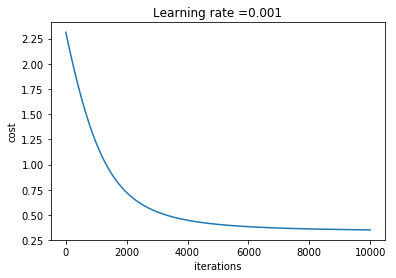

In [77]:
W, b = softmax(x, y, num_epochs=10000, learning_rate=1.e-3, print_cost=True, )

In [ ]:
print(W, b)
print(-W[0,0]/W[0,1])


## Ecoli
https://archive.ics.uci.edu/ml/datasets/ecoli

Abstract: This data contains protein localization sites


Number of Instances:  336 

Number of Attributes: 8 ( 7 predictive, 1 name )

	     
Attribute Information.

  1.  Sequence Name: Accession number for the SWISS-PROT database
  2.  mcg: McGeoch's method for signal sequence recognition.
  3.  gvh: von Heijne's method for signal sequence recognition.
  4.  lip: von Heijne's Signal Peptidase II consensus sequence score.
           Binary attribute.
  5.  chg: Presence of charge on N-terminus of predicted lipoproteins.
	   Binary attribute.
  6.  aac: score of discriminant analysis of the amino acid content of
	   outer membrane and periplasmic proteins.
  7. alm1: score of the ALOM membrane spanning region prediction program.
  8. alm2: score of ALOM program after excluding putative cleavable signal
	   regions from the sequence.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
%matplotlib inline
from sklearn.cross_validation import train_test_split
tf.reset_default_graph()

ecoli = pd.read_csv('/Users/blue/Desktop/Ecoli/ecoli.csv', header=None )
ecoli
x= ecoli.iloc[:,1:8].as_matrix()
y= ecoli.iloc[:, 8].as_matrix()
y = pd.get_dummies(y)

print ("x shape ", x.shape)
print ("y shape ", y.shape)



/Users/blue/anaconda/lib/python3.5/importlib/_bootstrap.py:222: RuntimeWarning: compiletime version 3.6 of module 'tensorflow.python.framework.fast_tensor_util' does not match runtime version 3.5
  return f(*args, **kwds)


x shape  (336, 7)
y shape  (336, 8)


/Users/blue/anaconda/lib/python3.5/site-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


In [9]:
def create_placeholders(n):
    X = tf.placeholder(tf.float64, shape=(None, n))     # we use None for unspecified sample size m
    Y = tf.placeholder(tf.float64, shape=(None, 8))
    print('X',X.shape)
    print('Y',Y.shape)
    return X, Y

def init_params(n):
    W = tf.Variable(tf.truncated_normal(shape=(n, 8), dtype=tf.float64), trainable=True, name="weights")
    b = tf.Variable(tf.zeros(shape=(1, 8 ), dtype=tf.float64), trainable=True, name="bias")
    print('W=',W.shape)
    print('b',b.shape)
    return W, b
 
# model function not needed, as the call to tf.nn.sigmoid_cross_entropy_with_logits in compute_cost
# already computes the model prediction. see its help. 
def model(X, W, b):
    Z = tf.matmul(X,W) + b  # matrix multiplication not element-wise multiplication
    print('Z',Z.shape)
    print('Z type=',type(Z))
    return Z

def compute_cost(Y,Z):
    logits = Z 
    labels = Y  
    cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(logits=logits, labels=labels))
    return cost


def softmax(x, y, num_epochs, learning_rate, print_cost=True):
    
    """ inputs:
    x=
    y=
    nump_epochs=
    learning_rate=
    print_cost=
    
    
        outputs:

    
    
    """
    
    
    
    #normalization
    mean= np.mean(x, axis=1)
    mean= mean.reshape(mean.shape[0],1)
    print('mean_shape', mean.shape)

    var= np.var(x, axis=1)
    var= var.reshape(var.shape[0],1)
    print('var_shape', var.shape)

    x_norm= (x-mean)/var
    print('x_norm', x_norm.shape)
    
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 100)

    
    print('X_train',X_train.shape)
    print('y_train',y_train.shape)
    print('y_train',type(y_train))
    print('X_test', X_test.shape)
    print('y_test',y_test.shape)
    
    graph = tf.Graph()
    with graph.as_default():
        m,n = X_train.shape
        costs = []
        X, Y = create_placeholders(n)
        W, b = init_params(n)
        Z = model(X, W, b)
        cost = compute_cost(Y,Z)
        optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate).minimize(cost) #training
        y_predict= tf.nn.softmax(Z)
        init = tf.global_variables_initializer()
        
    with tf.Session(graph=graph) as sess:
        sess.run(init)
        for epoch in range(num_epochs):
            _ , cost_ = sess.run([optimizer, cost], feed_dict={X:X_train, Y:y_train})
            costs.append(cost_) #list
            if print_cost == True and epoch % 1000 == 0:
                print ("Cost after epoch %i: %f" % (epoch, cost_))
        W_, b_ = sess.run([W, b])
        
        print('Z.shape=', Z.get_shape().as_list())
        print('Y.shape=', Y.get_shape().as_list())
        
        predictions = tf.equal(tf.argmax(y_predict,axis=1), tf.argmax(Y,axis=1))       
        accuracy = tf.reduce_mean(tf.cast(predictions, tf.float64))
        print('Train_Accuracy : ', sess.run(accuracy, feed_dict={X:X_train, Y:y_train}))
        print('Test_Accuracy : ', sess.run(accuracy, feed_dict={X:X_test, Y:y_test}))
    
        
    # plot the cost
    fig,ax = plt.subplots()
    ax.plot(np.squeeze(costs))
    ax.set_ylabel('cost')
    ax.set_xlabel('iterations')
    ax.set_title("Learning rate =" + str(learning_rate))
    #fig.show()
    return W_, b_ 


mean_shape (336, 1)
var_shape (336, 1)
x_norm (336, 7)
X_train (235, 7)
y_train (235, 8)
y_train <class 'pandas.core.frame.DataFrame'>
X_test (101, 7)
y_test (101, 8)
X (?, 7)
Y (?, 8)
W= (7, 8)
b (1, 8)
Z (?, 8)
Z type= <class 'tensorflow.python.framework.ops.Tensor'>
Cost after epoch 0: 1.999062
Cost after epoch 1000: 0.814519
Cost after epoch 2000: 0.652517
Cost after epoch 3000: 0.570220
Cost after epoch 4000: 0.519316
Cost after epoch 5000: 0.484571
Cost after epoch 6000: 0.459374
Cost after epoch 7000: 0.440288
Cost after epoch 8000: 0.425328
Cost after epoch 9000: 0.413275
Z.shape= [None, 8]
Y.shape= [None, 8]
Train_Accuracy :  0.889361702128
Test_Accuracy :  0.861386138614


NameError: name 'test_error' is not defined

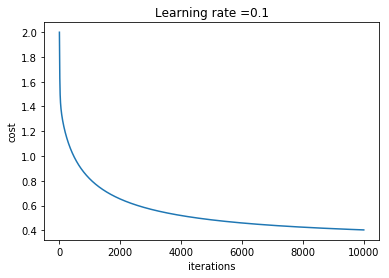

In [10]:
W, b = softmax(x, y, num_epochs=10000, learning_rate=1.e-1, print_cost=True, )

In [ ]:
print(W, b)
print(-W[0,0]/W[0,1])


## HIV
https://archive.ics.uci.edu/ml/datasets/HIV-1+protease+cleavage

The data contains lists of octamers (8 amino acids) and a flag (-1 or 1) depending on whether HIV-1 protease will cleave in the central position (between amino acids 4 and 5).

In [115]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
%matplotlib inline
from sklearn.cross_validation import train_test_split
tf.reset_default_graph()

df1 = pd.read_csv('/Users/blue/Desktop/HIV/746Data.txt', header=None )
df2 = pd.read_csv('/Users/blue/Desktop/HIV/1625Data.txt', header=None )
df3 = pd.read_csv('/Users/blue/Desktop/HIV/impensData.txt', header=None )
df4 = pd.read_csv('/Users/blue/Desktop/HIV/schillingData.txt', header=None )


frames = [df1, df2, df3, df4] #concatanate all data

HIV = pd.concat(frames).values
dic={'G':1, 'P':2, 'A':3, 'V':4, 'L':5, 'I':6, 'M':7, 'C':8, 'F':9, 
    'Y':10, 'W':11, 'H':12, 'K':13, 'R':14, 'Q':15, 'N':16, 'E':17,'D':18, 'S':19, 'T':20}


octamer= HIV[:,0]
#print(octamer[0][0])
aa_list=[]

for octamer_value in octamer:
    aa_seq=[]
    for aa in octamer_value:
        if(aa in dic.keys()):
            aa_seq.append(dic[aa])
            
    aa_list.append(aa_seq)
    
#print(aa_list)        
        
x= pd.DataFrame(aa_list)
print('x_shape',x.shape)
y= HIV[:,1]
y=pd.get_dummies(y)
print('y_shape',y.shape)

#normalization
mean= np.mean(x, axis=1)
mean= mean.reshape(mean.shape[0],1)
print('mean_shape', mean.shape)

var= np.var(x, axis=1)
var= var.reshape(var.shape[0],1)
print('var_shape', var.shape)

x_norm= (x-mean)/var
print('x_norm', x_norm.shape)


x_shape (6590, 8)
y_shape (6590, 2)
mean_shape (6590, 1)
var_shape (6590, 1)


/Users/blue/anaconda/lib/python3.5/site-packages/ipykernel_launcher.py:44: FutureWarning: reshape is deprecated and will raise in a subsequent release. Please use .values.reshape(...) instead
/Users/blue/anaconda/lib/python3.5/site-packages/ipykernel_launcher.py:48: FutureWarning: reshape is deprecated and will raise in a subsequent release. Please use .values.reshape(...) instead


ValueError: Unable to coerce to DataFrame, shape must be (6590, 8): given (6590, 1)

In [113]:
def create_placeholders(n):
    X = tf.placeholder(tf.float64, shape=(None, n))     # we use None for unspecified sample size m
    Y = tf.placeholder(tf.float64, shape=(None, 2))
    print('X',X.shape)
    print('Y',Y.shape)
    return X, Y

def init_params(n):
    W = tf.Variable(tf.truncated_normal(shape=(n, 2), dtype=tf.float64), trainable=True, name="weights")
    b = tf.Variable(tf.zeros(shape=(1, 2 ), dtype=tf.float64), trainable=True, name="bias")
    print('W=',W.shape)
    print('b',b.shape)
    return W, b
 
# model function not needed, as the call to tf.nn.sigmoid_cross_entropy_with_logits in compute_cost
# already computes the model prediction. see its help. 
def model(X, W, b):
    Z = tf.matmul(X,W) + b  # matrix multiplication not element-wise multiplication
    print('Z',Z.shape)
    print('Z type=',type(Z))
    return Z

def compute_cost(Y,Z):
    logits = Z 
    labels = Y  
    cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(logits=logits, labels=labels))
    return cost


def softmax(x, y, num_epochs, learning_rate, print_cost=True):

    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 100)

    
    print('X_train',X_train.shape)
    print('y_train',y_train.shape)
    print('y_train',type(y_train))
    print('X_test', X_test.shape)
    print('y_test',y_test.shape)
    
    graph = tf.Graph()
    with graph.as_default():
        m,n = X_train.shape
        costs = []
        X, Y = create_placeholders(n)
        W, b = init_params(n)
        Z = model(X, W, b)
        cost = compute_cost(Y,Z)
        optimizer = tf.train.GradientDescentOptimizer(learning_rate=learning_rate).minimize(cost) #training
        y_predict= tf.nn.softmax(Z)
        init = tf.global_variables_initializer()
        
    with tf.Session(graph=graph) as sess:
        sess.run(init)
        for epoch in range(num_epochs):
            _ , cost_ = sess.run([optimizer, cost], feed_dict={X:X_train, Y:y_train})
            costs.append(cost_)
            if print_cost == True and epoch % 1000 == 0:
                print ("Cost after epoch %i: %f" % (epoch, cost_))
        W_, b_ = sess.run([W, b])
        print('Z.shape=', Z.get_shape().as_list())
        print('Y.shape=', Y.get_shape().as_list())
        
        predictions = tf.equal(tf.argmax(y_predict,1), tf.argmax(Y,1))       
        accuracy = tf.reduce_mean(tf.cast(predictions, tf.float64))
        print('Train_Accuracy : ', sess.run(accuracy, feed_dict={X:X_train, Y:y_train}))
        print('Test_Accuracy : ', sess.run(accuracy, feed_dict={X:X_test, Y:y_test}))


    # plot the cost
    fig,ax = plt.subplots()
    ax.plot(np.squeeze(costs))
    ax.set_ylabel('cost')
    ax.set_xlabel('iterations')
    ax.set_title("Learning rate =" + str(learning_rate))
    #fig.show()
    return W_, b_  



X_train (4613, 8)
y_train (4613, 2)
y_train <class 'pandas.core.frame.DataFrame'>
X_test (1977, 8)
y_test (1977, 2)
X (?, 8)
Y (?, 2)
W= (8, 2)
b (1, 2)
Z (?, 2)
Z type= <class 'tensorflow.python.framework.ops.Tensor'>
Cost after epoch 0: 29.513892
Cost after epoch 1000: 19.115048
Cost after epoch 2000: 10.606476
Cost after epoch 3000: 5.774787
Cost after epoch 4000: 3.926424
Cost after epoch 5000: 3.268049
Cost after epoch 6000: 2.989452
Cost after epoch 7000: 2.846393
Cost after epoch 8000: 2.752129
Cost after epoch 9000: 2.675887
Z.shape= [None, 2]
Y.shape= [None, 2]
Train_Accuracy :  0.690656839367
Test_Accuracy :  0.700050581689


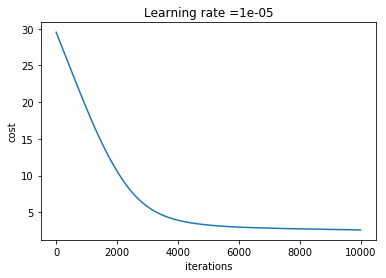

In [114]:
W, b = softmax(x, y, num_epochs=10000, learning_rate=1.e-5, print_cost=True, )